In [1]:
# creating my own ridge regression class

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

In [4]:
X, y = make_regression(n_samples = 100, n_features = 1, n_informative = 1, n_targets = 1, noise = 20, random_state= 20)

In [6]:
X.shape

(100, 1)

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 20)

In [9]:
# first applying linear regression and observing it's  performance

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
lr = LinearRegression()

In [12]:
lr.fit(X_train, y_train)

LinearRegression()

In [14]:
print(lr.coef_)
print(lr.intercept_)

[95.65747956]
2.6258999578330537


In [15]:
from sklearn.metrics import r2_score

In [17]:
r2_score(y_test, lr.predict(X_test))

0.9600527926980422

In [19]:
# now doing with ridge regression for different lambda values and seeing it's performance on both slope and r2 score

In [20]:
from sklearn.linear_model import Ridge

In [21]:
rd = Ridge(alpha= 10)

In [22]:
rd.fit(X_train, y_train)

Ridge(alpha=10)

In [24]:
print(rd.coef_)
print(rd.intercept_)

[85.80709036]
2.370945439684441


In [25]:
r2_score(y_test, rd.predict(X_test))

0.9453354145387705

In [26]:
rd2 = Ridge(alpha= 100)

In [27]:
rd2.fit(X_train, y_train)

Ridge(alpha=100)

In [28]:
print(rd2.coef_)
print(rd2.intercept_)

[44.53391701]
1.3026849060490924


In [29]:
r2_score(y_test, rd2.predict(X_test))

0.6691089753017416

In [30]:
# plotting all three graphs to see how closely it fits our data

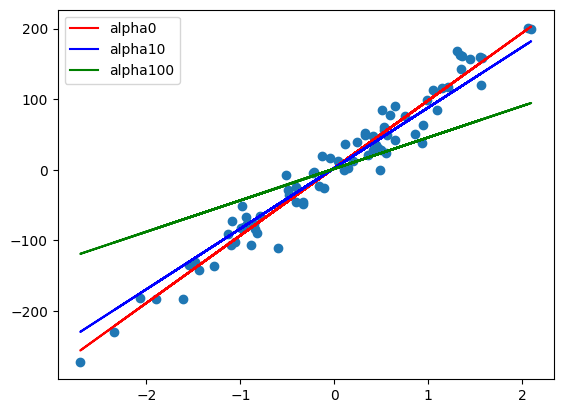

In [31]:
plt.scatter(X_train, y_train)
plt.plot(X_train, lr.predict(X_train), color = 'r', label = 'alpha0')
plt.plot(X_train, rd.predict(X_train), color = 'b', label = 'alpha10')
plt.plot(X_train, rd2.predict(X_train), color = 'g', label = 'alpha100')
plt.legend()
plt.show()

In [32]:
X_train.shape

(80, 1)

In [33]:
y_train.shape

(80,)

In [71]:
from ast import Num
class OwnRidge:

  def __init__(self, alpha = 0.001):
    self.alpha = alpha
    self.m = None
    self.b = None

  def fit(self, X_train, y_train):
    num = np.dot((y_train - np.mean(y_train)).reshape(1, -1), (X_train - np.mean(X_train)))
    den = np.dot((X_train - np.mean(X_train)).T, (X_train - np.mean(X_train))) + self.alpha
    self.m = num / den
    self.b = np.mean(y_train) - (self.m * np.mean(X_train))

  def predict(self, X_test):
    return (self.m * X_test + self.b)

In [72]:
rd1 = OwnRidge(10)

In [73]:
rd1.fit(X_train, y_train)

In [74]:
print(rd1.m)
print(rd1.b)

[[85.80709036]]
[[2.37094544]]


In [75]:
rd2 = OwnRidge(100)

In [76]:
rd2.fit(X_train, y_train)

In [77]:
print(rd2.m)
print(rd2.b)

[[44.53391701]]
[[1.30268491]]
